# Kyber-Controlled Adaptive Steganography
## Post-Quantum Image Steganography with ML-Guided Channel Selection

**Pipeline:**
1. Kyber + AES Encryption
2. ML-Based Channel & Texture Analysis
3. Kyber-Controlled Channel Weight Generation
4. Adaptive Domain Selection per Channel
5. Domain-Specific Embedding
6. Channel Recombination & Quality Metrics

## CELL 1 — Installation

In [ ]:
# ─────────────────────────────────────────────
# CELL 1: Install all dependencies
# ─────────────────────────────────────────────
!pip install -q liboqs-python pycryptodome opencv-python scikit-image pywavelets torchvision torch pillow timm
!apt-get update -qq
!apt-get install -y -qq build-essential cmake ninja-build git pkg-config libssl-dev

import os
if not os.path.exists('liboqs'):
    !git clone --depth 1 https://github.com/open-quantum-safe/liboqs.git
    %cd liboqs
    !cmake -DBUILD_SHARED_LIBS=ON -DCMAKE_INSTALL_PREFIX=/usr . -G Ninja -DCMAKE_BUILD_TYPE=Release
    !ninja install
    %cd ..

print('✅ Installation complete')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 26.3 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
(Reading database ... 122354 files and directories currently installed.)
Removing r-base-dev (4.5.3-1.2204.0) ...
dpkg: pkgconf: dependency problems, but removing anyway as you requested:
 libsndfile1-dev:amd64 depends on pkg-config; however:
  Package pkg-config is not installed.
  Package pkgconf which provides pkg-config is to be removed.
 libmkl-dev:amd64 depends on pkg-config; however:
  Package pkg-config is not installed.
  Package pkgconf which provides pkg-config is to be removed.
 libglib2.0-dev:amd64 depends on pkg-config; however:
  Package pkg-config is not installed.
  Package pkgconf which provides pkg-config is to be removed.
 libfontconfig-dev:amd64 depends on pkg-config; however:

## CELL 2 — Imports & Global Config

In [ ]:
# ─────────────────────────────────────────────
# CELL 2: Imports & Global Configuration
# ─────────────────────────────────────────────
import numpy as np
import cv2
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from skimage.metrics import structural_similarity as ssim
import pywt
import hashlib
import struct
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
import oqs

from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import os, zipfile, urllib.request

# ── Global Config ──────────────────────────────
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
BLOCK_SIZE   = 8
KEM_ALG      = 'Kyber768'
BLUE_BASE    = 0.55   # base blue channel allocation
SEED_GLOBAL  = 42

print(f'✅ Imports done | Device: {DEVICE}')

✅ Imports done | Device: cuda


## CELL 3 — Dataset Loading (Tiny ImageNet)

In [ ]:
# ─────────────────────────────────────────────
# CELL 3: Dataset — Tiny ImageNet
# ─────────────────────────────────────────────
def load_tiny_imagenet(root='/content/tiny-imagenet-200', batch_size=1):
    zip_path = root + '.zip'
    url = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
    if not os.path.exists(root):
        if not os.path.exists(zip_path):
            print('Downloading Tiny ImageNet...')
            urllib.request.urlretrieve(url, zip_path)
        print('Extracting...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall('/content/')

    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])
    train_dir = os.path.join(root, 'train')
    dataset   = ImageFolder(train_dir, transform=transform)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                           num_workers=2, pin_memory=(DEVICE == 'cuda'))
    print(f'✅ Dataset ready: {len(dataset)} images')
    return loader


def tensor_to_uint8(tensor):
    """Convert a (C,H,W) or (1,C,H,W) tensor to uint8 HxWxC numpy."""
    if tensor.dim() == 4:
        tensor = tensor.squeeze(0)
    img = tensor.permute(1, 2, 0).cpu().numpy()
    return np.clip(img * 255, 0, 255).astype(np.uint8)


def get_image(loader):
    img_t, label = next(iter(loader))
    return tensor_to_uint8(img_t), label.item()


loader = load_tiny_imagenet()

Extracting...
✅ Dataset ready: 100000 images


### VIZ 3 — Sample Cover & Hidden Images

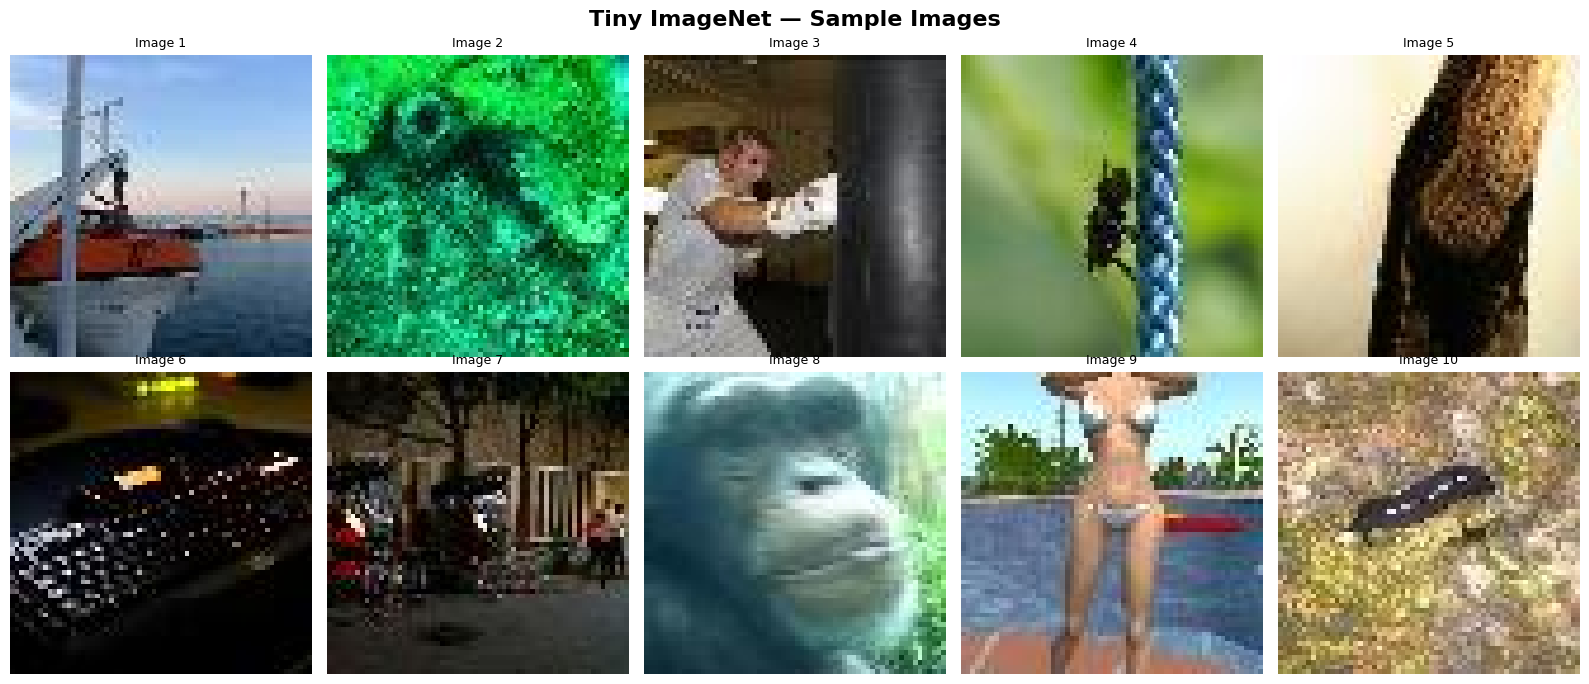

✅ Sample images saved → sample_images.png


In [ ]:
# ─────────────────────────────────────────────
# VIZ 3: Visualise Sample Images from Dataset
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Tiny ImageNet — Sample Images', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img, _ = get_image(loader)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Image {i+1}', fontsize=9)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample images saved → sample_images.png')

## CELL 4 — Step 1: Kyber + AES Encryption

In [ ]:
# ─────────────────────────────────────────────
# CELL 4: Step 1 — Kyber + AES Encryption
# ─────────────────────────────────────────────
class KyberAESCipher:
    """
    Hybrid post-quantum cipher:
    - Kyber KEM for key exchange
    - AES-256-CBC for symmetric encryption
    - SHA-256 key derivation from shared secret
    """
    def __init__(self, kem_alg=KEM_ALG):
        self.kem_alg = kem_alg

    def encrypt(self, plaintext: bytes):
        kem = oqs.KeyEncapsulation(self.kem_alg)
        public_key = kem.generate_keypair()
        ciphertext_kem, shared_secret = kem.encap_secret(public_key)

        aes_key = hashlib.sha256(shared_secret).digest()  # 32 bytes → AES-256
        iv      = hashlib.md5(shared_secret + b'IV').digest()  # deterministic IV
        cipher  = AES.new(aes_key, AES.MODE_CBC, iv)
        enc_data = cipher.encrypt(pad(plaintext, AES.block_size))

        return {
            'ciphertext_kem':  ciphertext_kem,
            'encrypted_bytes': enc_data,
            'iv':              iv,
            'shared_secret':   shared_secret,
            'public_key':      public_key,
            'kem':             kem,
        }

    def decrypt(self, enc_result: dict, encrypted_bytes: bytes) -> bytes:
        shared_secret = enc_result['shared_secret']
        aes_key = hashlib.sha256(shared_secret).digest()
        cipher  = AES.new(aes_key, AES.MODE_CBC, enc_result['iv'])
        return unpad(cipher.decrypt(encrypted_bytes), AES.block_size)

    def get_seed_from_secret(self, shared_secret: bytes) -> int:
        """Derive deterministic integer seed from Kyber shared secret."""
        return int.from_bytes(hashlib.sha256(shared_secret).digest()[:4], 'big')


def prepare_hidden_image(img: np.ndarray) -> bytes:
    """Serialise image with shape metadata prepended."""
    img = cv2.resize(img, (64, 64))
    h, w, c = img.shape
    header  = struct.pack('HHH', h, w, c)
    return header + img.flatten().tobytes()


def recover_hidden_image(decrypted_bytes: bytes) -> np.ndarray:
    """Reconstruct image from decrypted bytes."""
    h, w, c = struct.unpack('HHH', decrypted_bytes[:6])
    data = np.frombuffer(decrypted_bytes[6:], dtype=np.uint8)
    return data.reshape((h, w, c))


print('✅ KyberAESCipher defined')

✅ KyberAESCipher defined


### VIZ 4 — Encryption Visualisation

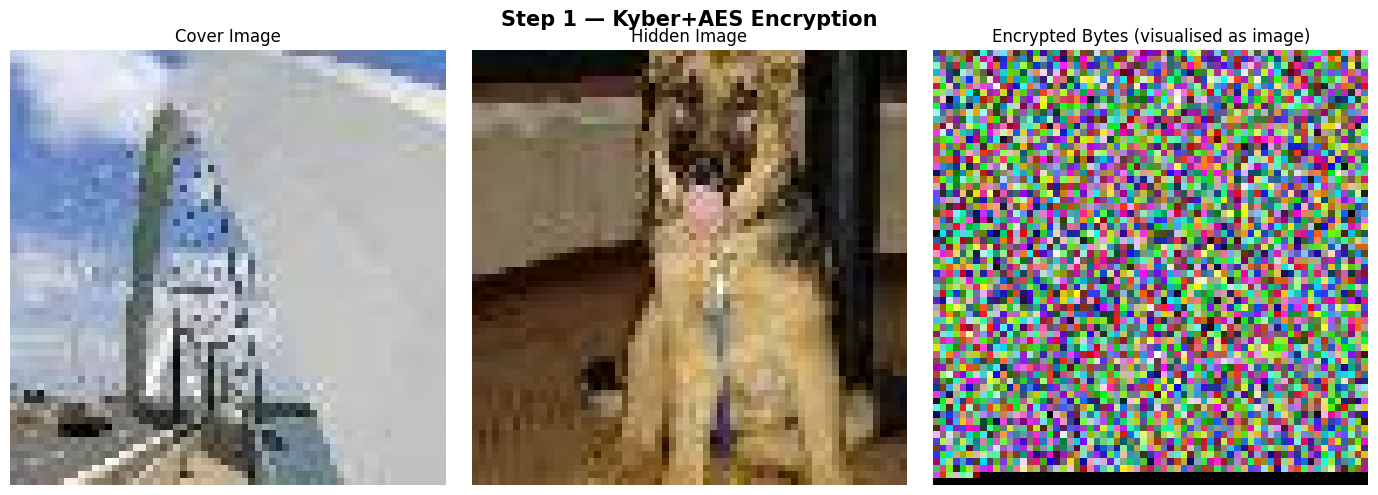

Payload size: 12294 bytes → Encrypted: 12304 bytes


In [ ]:
# ─────────────────────────────────────────────
# VIZ 4: Show cover, hidden, and encrypted bytes
# ─────────────────────────────────────────────
cover_img, _  = get_image(loader)
hidden_img, _ = get_image(loader)

cipher    = KyberAESCipher()
payload   = prepare_hidden_image(hidden_img)
enc_result = cipher.encrypt(payload)
encrypted_bytes = enc_result['encrypted_bytes']

# Visualise encrypted bytes as a random-looking image
n = len(encrypted_bytes)
side = int(np.ceil(np.sqrt(n / 3)))
padded = encrypted_bytes + b'\x00' * (side * side * 3 - n)
enc_vis = np.frombuffer(padded, dtype=np.uint8).reshape(side, side, 3)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Step 1 — Kyber+AES Encryption', fontsize=15, fontweight='bold')

axes[0].imshow(cover_img);  axes[0].set_title('Cover Image');  axes[0].axis('off')
axes[1].imshow(hidden_img); axes[1].set_title('Hidden Image'); axes[1].axis('off')
axes[2].imshow(enc_vis);    axes[2].set_title('Encrypted Bytes (visualised as image)'); axes[2].axis('off')

plt.tight_layout()
plt.savefig('step1_encryption.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Payload size: {len(payload)} bytes → Encrypted: {len(encrypted_bytes)} bytes')

## CELL 5 — Step 2: ML-Based Channel & Texture Analysis

In [ ]:
# ─────────────────────────────────────────────
# CELL 5: Step 2 — ML-Based Texture & Channel Analysis
#
# Uses a pretrained CNN feature extractor (EfficientNet-B0 backbone)
# to compute per-block texture complexity, dominant channel, and
# edge vs smooth vs textured classification.
# ─────────────────────────────────────────────
import timm

class BlockFeatureExtractor(nn.Module):
    """
    Lightweight CNN encoder that maps an 8×8 RGB block → feature vector.
    Uses the first few layers of EfficientNet-B0 pretrained on ImageNet.
    The feature variance is used as texture complexity score.
    """
    def __init__(self):
        super().__init__()
        backbone = timm.create_model('efficientnet_b0', pretrained=True,
                                     features_only=True, out_indices=[1])
        self.stem = backbone

    def forward(self, x):
        feats = self.stem(x)[0]   # (B, C, H, W)
        return feats.flatten(1)   # (B, C*H*W)


class TextureClassifierNet(nn.Module):
    """
    MLP head that classifies block texture into:
    0=smooth, 1=textured, 2=edge
    Trained via self-supervised proxy using gradient magnitude + variance.
    """
    def __init__(self, in_features):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.classifier(x)


class MLTextureAnalyzer:
    """
    Full texture analysis pipeline:
    1. Backbone feature extraction per block
    2. Texture classification (smooth/textured/edge)
    3. Per-channel energy & dominant color computation
    """
    LABEL_MAP = {0: 'smooth', 1: 'textured', 2: 'edge'}

    def __init__(self, device=DEVICE):
        self.device = device
        self.transform = T.Compose([
            T.ToTensor(),
            T.Resize((32, 32), antialias=True),   # backbone needs > 8px
            T.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225]),
        ])

        # Feature extractor
        self.extractor = BlockFeatureExtractor().to(device).eval()

        # Determine feature dimension with dummy pass
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 32, 32).to(device)
            feat_dim = self.extractor(dummy).shape[1]

        # Texture classifier (trained inline via pseudo-labels)
        self.classifier = TextureClassifierNet(feat_dim).to(device)
        self._pretrain_classifier(feat_dim)

    def _pseudo_label(self, block_np: np.ndarray) -> int:
        """Generate pseudo ground-truth label using classical CV signals."""
        gray = cv2.cvtColor(block_np, cv2.COLOR_RGB2GRAY).astype(np.float32)
        variance = float(np.var(gray))
        # Edge magnitude
        gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0)
        gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1)
        edge_mag = float(np.mean(np.sqrt(gx**2 + gy**2)))
        if edge_mag > 15:
            return 2  # edge
        if variance > 25:
            return 1  # textured
        return 0      # smooth

    def _pretrain_classifier(self, feat_dim, n_samples=500, epochs=20):
        """Self-supervised training using random patches + pseudo-labels."""
        self.classifier.train()
        optimizer = torch.optim.Adam(self.classifier.parameters(), lr=1e-3)
        loss_fn   = nn.CrossEntropyLoss()

        np.random.seed(SEED_GLOBAL)
        for epoch in range(epochs):
            # Generate random synthetic blocks for training
            batch_feats, batch_labels = [], []
            for _ in range(n_samples // epochs):
                rng_type = np.random.randint(3)
                if rng_type == 0:   # smooth
                    block = np.full((8, 8, 3),
                                    np.random.randint(0, 256, 3), dtype=np.uint8)
                    block = block + np.random.randint(-5, 5, block.shape).astype(np.int16)
                    block = np.clip(block, 0, 255).astype(np.uint8)
                elif rng_type == 1: # textured
                    block = np.random.randint(0, 256, (8, 8, 3), dtype=np.uint8)
                else:               # edge
                    block = np.zeros((8, 8, 3), dtype=np.uint8)
                    block[:4, :, :] = np.random.randint(200, 256)
                    block[4:, :, :] = np.random.randint(0, 50)

                t = self.transform(block).unsqueeze(0).to(self.device)
                with torch.no_grad():
                    feat = self.extractor(t)
                batch_feats.append(feat)
                batch_labels.append(self._pseudo_label(block))

            feats  = torch.cat(batch_feats, 0)
            labels = torch.tensor(batch_labels, dtype=torch.long).to(self.device)
            optimizer.zero_grad()
            loss = loss_fn(self.classifier(feats), labels)
            loss.backward()
            optimizer.step()

        self.classifier.eval()
        print('✅ Texture classifier pre-trained')

    @torch.no_grad()
    def extract_features(self, block_np: np.ndarray) -> torch.Tensor:
        t = self.transform(block_np).unsqueeze(0).to(self.device)
        return self.extractor(t)

    @torch.no_grad()
    def classify_block(self, block_np: np.ndarray) -> str:
        feat  = self.extract_features(block_np)
        logit = self.classifier(feat)
        label = int(logit.argmax(dim=1).item())
        return self.LABEL_MAP[label]

    def channel_energy(self, block_np: np.ndarray) -> np.ndarray:
        """Per-channel RMS energy of the block."""
        energy = np.array([
            np.sqrt(np.mean(block_np[:, :, c].astype(np.float32) ** 2))
            for c in range(3)
        ])
        return energy

    def dominant_channel(self, block_np: np.ndarray) -> int:
        return int(np.argmax(self.channel_energy(block_np)))

    def analyze_image(self, image: np.ndarray):
        """
        Analyse full image block-by-block.
        Returns maps: texture_map, dominant_channel_map, energy_map.
        """
        h, w = image.shape[:2]
        rows, cols = h // BLOCK_SIZE, w // BLOCK_SIZE
        texture_map  = np.zeros((rows, cols), dtype=np.uint8)
        dom_chan_map  = np.zeros((rows, cols), dtype=np.uint8)
        energy_map   = np.zeros((rows, cols, 3), dtype=np.float32)

        label2int = {'smooth': 0, 'textured': 1, 'edge': 2}
        for r in range(rows):
            for c in range(cols):
                y0, x0 = r * BLOCK_SIZE, c * BLOCK_SIZE
                block   = image[y0:y0+BLOCK_SIZE, x0:x0+BLOCK_SIZE]
                texture_map[r, c] = label2int[self.classify_block(block)]
                dom_chan_map[r, c] = self.dominant_channel(block)
                energy_map[r, c]  = self.channel_energy(block)

        return texture_map, dom_chan_map, energy_map


# Instantiate the analyzer (runs pre-training)
analyzer = MLTextureAnalyzer()
print('✅ MLTextureAnalyzer ready')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

✅ Texture classifier pre-trained
✅ MLTextureAnalyzer ready


### VIZ 5 — Texture Analysis Maps

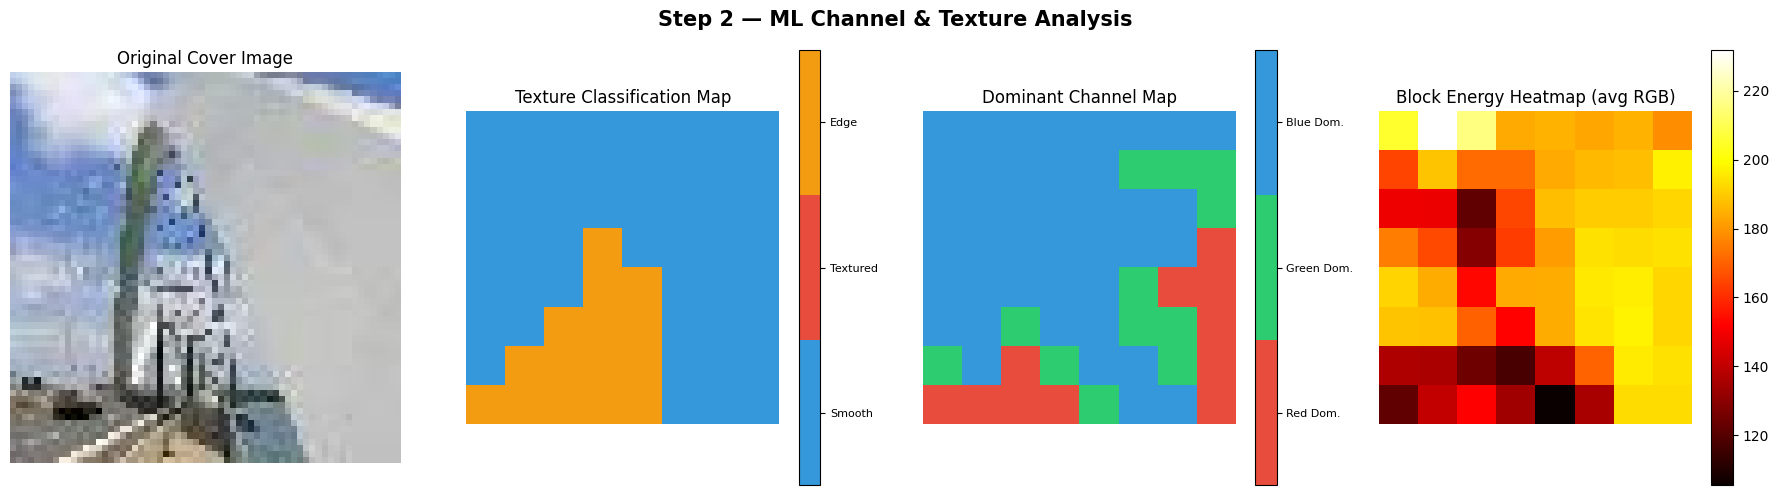

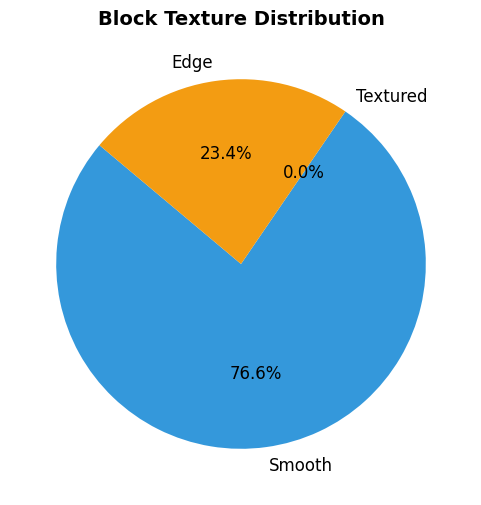

✅ Texture analysis visualised


In [ ]:
# ─────────────────────────────────────────────
# VIZ 5: Colour-Coded Texture Analysis Map
# ─────────────────────────────────────────────
texture_map, dom_chan_map, energy_map = analyzer.analyze_image(cover_img)

# Upsample maps to image resolution for display
def upsample_map(m, scale=BLOCK_SIZE):
    return np.repeat(np.repeat(m, scale, axis=0), scale, axis=1)

tex_up  = upsample_map(texture_map)
dom_up  = upsample_map(dom_chan_map)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Step 2 — ML Channel & Texture Analysis', fontsize=15, fontweight='bold')

axes[0].imshow(cover_img)
axes[0].set_title('Original Cover Image'); axes[0].axis('off')

# Texture map: 0=smooth(blue), 1=textured(red), 2=edge(yellow)
tex_cmap = ListedColormap(['#3498db', '#e74c3c', '#f39c12'])
im = axes[1].imshow(tex_up, cmap=tex_cmap, vmin=0, vmax=2)
cbar = plt.colorbar(im, ax=axes[1], ticks=[0.33, 1.0, 1.67])
cbar.ax.set_yticklabels(['Smooth', 'Textured', 'Edge'], fontsize=8)
axes[1].set_title('Texture Classification Map'); axes[1].axis('off')

# Dominant channel map: 0=R(red), 1=G(green), 2=B(blue)
dom_cmap = ListedColormap(['#e74c3c', '#2ecc71', '#3498db'])
im2 = axes[2].imshow(dom_up, cmap=dom_cmap, vmin=0, vmax=2)
cbar2 = plt.colorbar(im2, ax=axes[2], ticks=[0.33, 1.0, 1.67])
cbar2.ax.set_yticklabels(['Red Dom.', 'Green Dom.', 'Blue Dom.'], fontsize=8)
axes[2].set_title('Dominant Channel Map'); axes[2].axis('off')

# Channel energy heatmaps (average R,G,B per block)
avg_energy = energy_map.mean(axis=2)
im3 = axes[3].imshow(upsample_map(avg_energy), cmap='hot')
plt.colorbar(im3, ax=axes[3])
axes[3].set_title('Block Energy Heatmap (avg RGB)'); axes[3].axis('off')

plt.tight_layout()
plt.savefig('step2_texture_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Block-wise texture distribution pie chart ──
labels_txt = ['Smooth', 'Textured', 'Edge']
counts = [(texture_map == i).sum() for i in range(3)]
colors = ['#3498db', '#e74c3c', '#f39c12']

fig2, ax = plt.subplots(figsize=(6, 6))
ax.pie(counts, labels=labels_txt, colors=colors, autopct='%1.1f%%',
       startangle=140, textprops={'fontsize': 12})
ax.set_title('Block Texture Distribution', fontsize=14, fontweight='bold')
plt.savefig('step2_texture_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Texture analysis visualised')

## CELL 6 — Step 3: Kyber-Controlled Channel Weight Generation

In [ ]:
# ─────────────────────────────────────────────
# CELL 6: Step 3 — Kyber-Controlled Channel Weight Generation
#
# The Kyber shared secret is used as a PRNG seed to generate
# per-block channel weights. This ties the embedding pattern
# to the cryptographic key — only a holder of the key can
# replicate the exact channel allocation used for embedding.
# ─────────────────────────────────────────────

class KyberChannelWeightGenerator:
    """
    Generates per-block RGB channel weights from Kyber shared secret.

    Formula:
        base       = [R_base, G_base, B_base]  (blue biased, sums to 1)
        adaptive   = f(block content)
        kyber_mod  = PRNG(seed + block_id) ∈ [0.85, 1.15]
        final_w    = softmax(base * adaptive * kyber_mod)
    """
    BASE_WEIGHTS   = np.array([0.20, 0.25, BLUE_BASE])   # R, G, B
    KYBER_MOD_RANGE = (0.85, 1.15)

    def __init__(self, shared_secret: bytes, analyzer: MLTextureAnalyzer):
        self.seed     = int.from_bytes(hashlib.sha256(shared_secret).digest()[:4], 'big')
        self.analyzer = analyzer
        self._rng     = np.random.RandomState(self.seed)

    def _kyber_modulation(self, block_id: int) -> np.ndarray:
        """Deterministic per-block modulation derived from Kyber secret."""
        rng = np.random.RandomState(self.seed ^ block_id)
        lo, hi = self.KYBER_MOD_RANGE
        return rng.uniform(lo, hi, size=3)

    def _adaptive_factor(self, block_np: np.ndarray) -> np.ndarray:
        """Content-adaptive weight modifier based on per-channel variance."""
        factors = np.ones(3, dtype=np.float64)
        for c in range(3):
            var_c = np.var(block_np[:, :, c].astype(np.float64))
            # High variance → reduce embedding in that channel (more visible)
            # Low variance  → increase embedding (changes less visible)
            factors[c] = 1.0 / (1.0 + 0.02 * var_c)

        # Extra blue boost — human eye least sensitive to blue
        blue_var = np.var(block_np[:, :, 2].astype(np.float64))
        if blue_var < 10:
            factors[2] *= 0.7   # flat blue region — reduce to avoid saturation
        else:
            factors[2] *= 1.2   # textured blue — safe to embed more

        return factors

    def get_weights(self, block_np: np.ndarray, block_id: int) -> np.ndarray:
        """Compute final normalised channel weights for a block."""
        base    = self.BASE_WEIGHTS.copy()
        adapt   = self._adaptive_factor(block_np)
        kyber   = self._kyber_modulation(block_id)
        raw     = base * adapt * kyber
        return raw / raw.sum()

    def generate_weight_maps(self, image: np.ndarray):
        """Pre-compute weights for all blocks — for analysis/visualization."""
        h, w = image.shape[:2]
        rows, cols = h // BLOCK_SIZE, w // BLOCK_SIZE
        weight_map = np.zeros((rows, cols, 3), dtype=np.float32)

        for r in range(rows):
            for c in range(cols):
                y0, x0  = r * BLOCK_SIZE, c * BLOCK_SIZE
                block   = image[y0:y0+BLOCK_SIZE, x0:x0+BLOCK_SIZE]
                bid     = r * cols + c
                weight_map[r, c] = self.get_weights(block, bid)

        return weight_map


# Instantiate with the Kyber shared secret from Cell 4
weight_gen = KyberChannelWeightGenerator(enc_result['shared_secret'], analyzer)
print('✅ KyberChannelWeightGenerator ready')

✅ KyberChannelWeightGenerator ready


### VIZ 6 — Channel Weight Heatmaps

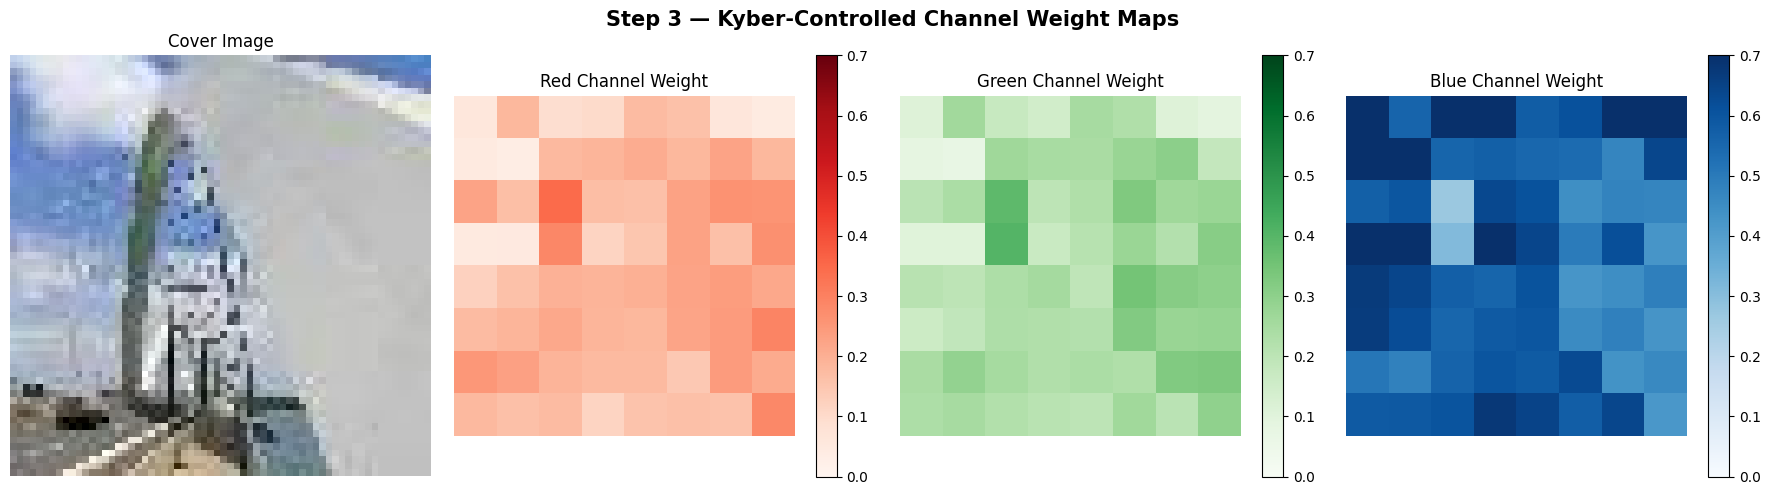

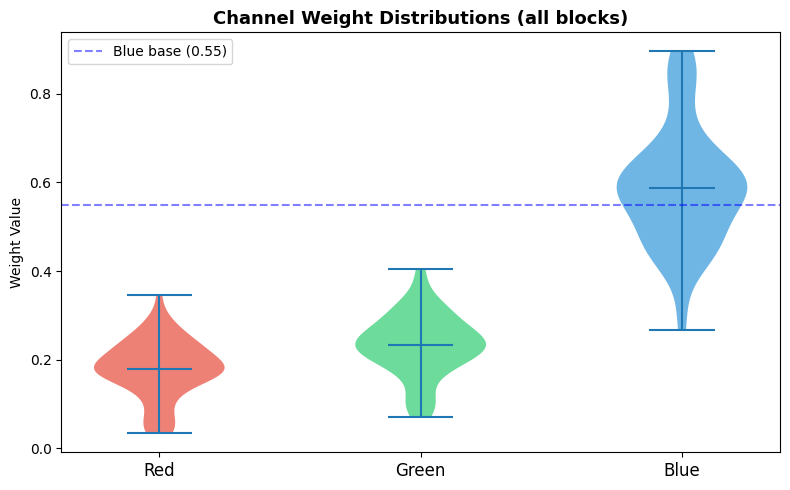

Avg weights → R:0.179  G:0.233  B:0.588


In [ ]:
# ─────────────────────────────────────────────
# VIZ 6: Per-block Channel Weight Heatmaps
# ─────────────────────────────────────────────
weight_map = weight_gen.generate_weight_maps(cover_img)
chan_names = ['Red Channel Weight', 'Green Channel Weight', 'Blue Channel Weight']
chan_cmaps = ['Reds', 'Greens', 'Blues']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Step 3 — Kyber-Controlled Channel Weight Maps', fontsize=15, fontweight='bold')

axes[0].imshow(cover_img); axes[0].set_title('Cover Image'); axes[0].axis('off')

for i in range(3):
    im = axes[i+1].imshow(upsample_map(weight_map[:, :, i]),
                           cmap=chan_cmaps[i], vmin=0, vmax=0.7)
    plt.colorbar(im, ax=axes[i+1])
    axes[i+1].set_title(chan_names[i]); axes[i+1].axis('off')

plt.tight_layout()
plt.savefig('step3_channel_weights.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Weight distribution violin plot ──
fig2, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [weight_map[:, :, c].flatten() for c in range(3)]
parts = ax.violinplot(data_to_plot, positions=[1, 2, 3], showmeans=True)
for pc, col in zip(parts['bodies'], ['#e74c3c', '#2ecc71', '#3498db']):
    pc.set_facecolor(col); pc.set_alpha(0.7)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Red', 'Green', 'Blue'], fontsize=12)
ax.set_ylabel('Weight Value')
ax.set_title('Channel Weight Distributions (all blocks)', fontsize=13, fontweight='bold')
ax.axhline(BLUE_BASE, color='blue', linestyle='--', alpha=0.5, label=f'Blue base ({BLUE_BASE})')
ax.legend()
plt.tight_layout()
plt.savefig('step3_weight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Avg weights → R:{weight_map[:,:,0].mean():.3f}  G:{weight_map[:,:,1].mean():.3f}  B:{weight_map[:,:,2].mean():.3f}')

## CELL 7 — Step 4: ML-Based Domain Selection Per Channel

In [ ]:
# ─────────────────────────────────────────────
# CELL 7: Step 4 — Adaptive Domain Selection per Channel
#
# For each (block, channel) pair the embedding domain is chosen:
#   smooth  → DCT (frequency domain)
#   textured → Spatial LSB (multi-bit)
#   edge    → DWT (wavelet domain)
#
# Blue channel gets more aggressive: multi-bit LSB + multiple DCT coefficients
# ─────────────────────────────────────────────

class DomainSelector:
    """
    Selects embedding domain per (block, channel) using ML texture signal.
    Blue channel always gets a more aggressive strategy.
    """
    # capacity: how many bits to embed per block in each domain
    DCT_CAPACITY   = {'R': 4,  'G': 5,  'B': 8}   # multiple DCT coefficients for B
    LSB_BITS       = {'R': 1,  'G': 1,  'B': 2}   # multi-bit LSB for blue
    DWT_CAPACITY   = {'R': 4,  'G': 5,  'B': 7}

    CHAN_NAMES = ['R', 'G', 'B']

    def select_domain(self, texture_label: str, channel_idx: int) -> str:
        """
        Returns: 'dct', 'lsb', 'dwt'
        Blue channel (2) biased towards more aggressive multi-domain.
        """
        if channel_idx == 2:   # Blue — more aggressive
            if texture_label == 'smooth':
                return 'multi_dct'    # multiple DCT coefficients
            elif texture_label == 'edge':
                return 'dwt'          # wavelet
            else:
                return 'multi_lsb'    # 2-bit LSB
        else:                  # Red / Green — standard
            if texture_label == 'smooth':
                return 'dct'
            elif texture_label == 'textured':
                return 'lsb'
            else:
                return 'dwt'

    def capacity_bits(self, domain: str, channel_idx: int) -> int:
        chan = self.CHAN_NAMES[channel_idx]
        mapping = {
            'dct':       self.DCT_CAPACITY[chan],
            'multi_dct': self.DCT_CAPACITY[chan] * 2,
            'lsb':       int((BLOCK_SIZE**2) * self.LSB_BITS[chan] * 0.5),
            'multi_lsb': int((BLOCK_SIZE**2) * self.LSB_BITS[chan]),
            'dwt':       self.DWT_CAPACITY[chan],
        }
        return mapping.get(domain, 4)


domain_sel = DomainSelector()
print('✅ DomainSelector ready')
print('\nDomain assignment table:')
print(f'{"Texture":<12} {"R Channel":<14} {"G Channel":<14} {"B Channel":<14}')
for tex in ['smooth', 'textured', 'edge']:
    row = [domain_sel.select_domain(tex, c) for c in range(3)]
    print(f'{tex:<12} {row[0]:<14} {row[1]:<14} {row[2]:<14}')

✅ DomainSelector ready

Domain assignment table:
Texture      R Channel      G Channel      B Channel     
smooth       dct            dct            multi_dct     
textured     lsb            lsb            multi_lsb     
edge         dwt            dwt            dwt           


### VIZ 7 — Domain Selection Map

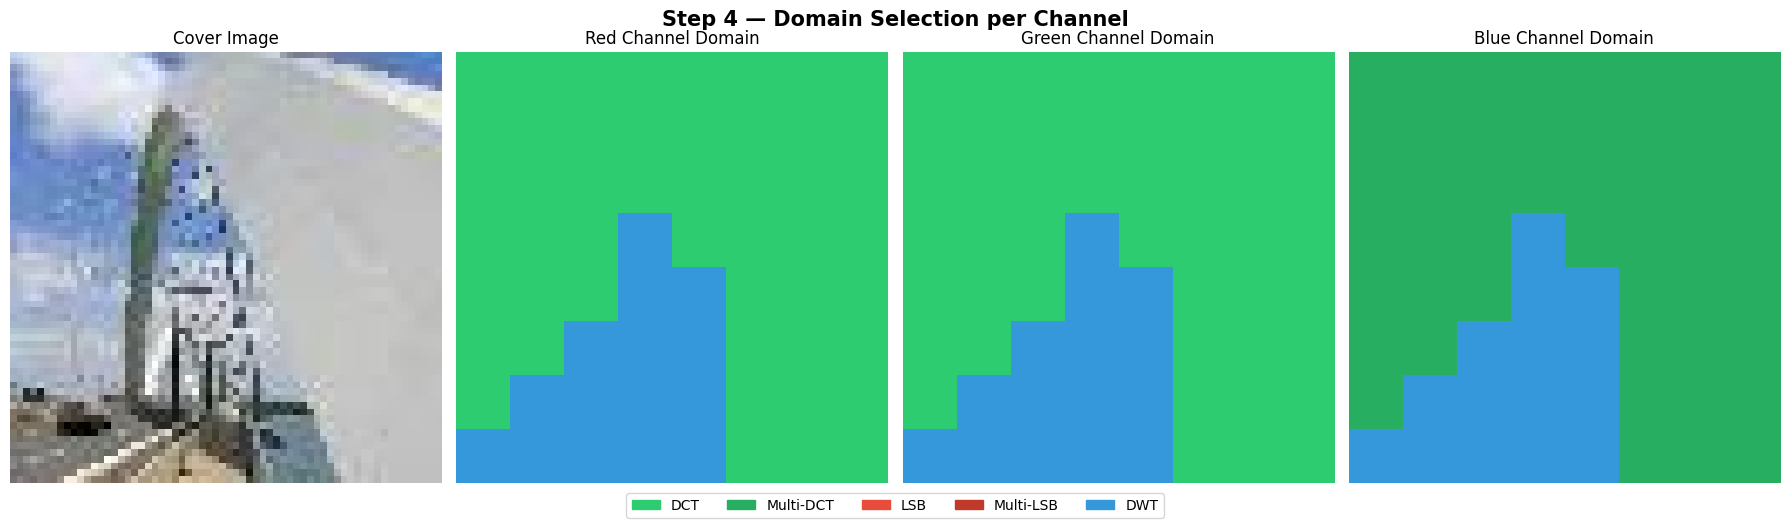

✅ Domain selection map saved


In [ ]:
# ─────────────────────────────────────────────
# VIZ 7: Per-Block Domain Selection Map (one map per channel)
# ─────────────────────────────────────────────
h, w = cover_img.shape[:2]
rows, cols = h // BLOCK_SIZE, w // BLOCK_SIZE

domain_str2int = {'dct': 0, 'multi_dct': 1, 'lsb': 2, 'multi_lsb': 3, 'dwt': 4}
domain_map = np.zeros((rows, cols, 3), dtype=np.uint8)

for r in range(rows):
    for c in range(cols):
        tex_label = ['smooth', 'textured', 'edge'][int(texture_map[r, c])]
        for ch in range(3):
            d = domain_sel.select_domain(tex_label, ch)
            domain_map[r, c, ch] = domain_str2int[d]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Step 4 — Domain Selection per Channel', fontsize=15, fontweight='bold')
axes[0].imshow(cover_img); axes[0].set_title('Cover Image'); axes[0].axis('off')

dom_cmap2 = ListedColormap(['#2ecc71', '#27ae60', '#e74c3c', '#c0392b', '#3498db'])
dom_labels = ['DCT', 'Multi-DCT', 'LSB', 'Multi-LSB', 'DWT']
chan_names2 = ['Red', 'Green', 'Blue']

for ch in range(3):
    im = axes[ch+1].imshow(upsample_map(domain_map[:, :, ch]),
                            cmap=dom_cmap2, vmin=0, vmax=4)
    axes[ch+1].set_title(f'{chan_names2[ch]} Channel Domain'); axes[ch+1].axis('off')

# shared colorbar
from matplotlib.patches import Patch
legend_patches = [Patch(color=dom_cmap2(i/4), label=dom_labels[i]) for i in range(5)]
fig.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('step4_domain_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Domain selection map saved')

## CELL 8 — Step 5: Domain-Specific Embedding Engines

In [ ]:
# ─────────────────────────────────────────────
# CELL 8: Step 5 — Embedding Engines
#
# All embed_* functions accept (channel_block: np.ndarray, bits: str)
# and return a modified channel block of the same shape.
# ─────────────────────────────────────────────

def embed_dct(channel: np.ndarray, bits: str, num_coeffs: int = 4) -> np.ndarray:
    """
    DCT-domain embedding: modifies mid-frequency coefficients.
    Embeds 1 bit per coefficient (LSB of rounded integer value).
    """
    ch = channel.astype(np.float32)
    dct_block = cv2.dct(ch)
    flat      = dct_block.flatten()
    # Mid-frequency zig-zag indices (skip DC at 0)
    indices = list(range(1, 1 + min(num_coeffs, len(bits))))

    for i, idx in enumerate(indices):
        if i >= len(bits):
            break
        rounded = int(round(flat[idx]))
        flat[idx] = float((rounded & ~1) | int(bits[i]))

    result = cv2.idct(flat.reshape(dct_block.shape))
    return np.clip(result, 0, 255).astype(np.uint8)


def embed_multi_dct(channel: np.ndarray, bits: str) -> np.ndarray:
    """Multi-coefficient DCT — for blue channel (more capacity)."""
    return embed_dct(channel, bits, num_coeffs=8)


def embed_lsb(channel: np.ndarray, bits: str, n_bits: int = 1) -> np.ndarray:
    """
    Spatial LSB substitution.
    n_bits=1: standard 1-bit LSB
    n_bits=2: 2-bit LSB (blue channel)
    """
    flat    = channel.flatten().astype(np.uint8)
    mask    = ~((1 << n_bits) - 1) & 0xFF
    i_bit   = 0
    i_pixel = 0
    while i_bit < len(bits) and i_pixel < len(flat):
        chunk = bits[i_bit:i_bit + n_bits]
        if len(chunk) < n_bits:
            chunk = chunk.ljust(n_bits, '0')
        val = int(chunk, 2)
        flat[i_pixel] = int(int(flat[i_pixel]) & mask) | val
        i_bit   += n_bits
        i_pixel += 1
    return flat.reshape(channel.shape)


def embed_multi_lsb(channel: np.ndarray, bits: str) -> np.ndarray:
    """2-bit LSB for blue channel."""
    return embed_lsb(channel, bits, n_bits=2)


def embed_dwt(channel: np.ndarray, bits: str, wavelet: str = 'haar') -> np.ndarray:
    """
    DWT-domain embedding: modifies LL subband coefficients.
    Suitable for edge-dominant blocks.
    """
    ch = channel.astype(np.float32)
    cA, (cH, cV, cD) = pywt.dwt2(ch, wavelet)
    flat = cA.flatten()

    for i, bit in enumerate(bits[:len(flat)]):
        rounded = int(round(flat[i]))
        flat[i] = float((rounded & ~1) | int(bit))

    cA_mod = flat.reshape(cA.shape)
    result = pywt.idwt2((cA_mod, (cH, cV, cD)), wavelet)
    # Crop to original size (dwt can change size by 1)
    result = result[:channel.shape[0], :channel.shape[1]]
    return np.clip(result, 0, 255).astype(np.uint8)


EMBED_FN_MAP = {
    'dct':       embed_dct,
    'multi_dct': embed_multi_dct,
    'lsb':       embed_lsb,
    'multi_lsb': embed_multi_lsb,
    'dwt':       embed_dwt,
}

print('✅ Embedding engines defined')

✅ Embedding engines defined


## CELL 9 — Step 5+6: Full Embedding Pipeline

In [ ]:
# ─────────────────────────────────────────────
# CELL 9: Full Adaptive Embedding Pipeline
# Ties together Steps 3–6
# ─────────────────────────────────────────────

class AdaptiveStegoEmbedder:
    """
    Full pipeline:
    1. Convert payload to bit stream
    2. For each 8×8 block:
        a. ML texture classification
        b. Kyber-controlled channel weights
        c. Domain selection per channel
        d. Embed bits in each channel
    3. Reconstruct stego image
    """
    def __init__(self, analyzer: MLTextureAnalyzer,
                 weight_gen: KyberChannelWeightGenerator,
                 domain_sel: DomainSelector):
        self.analyzer   = analyzer
        self.weight_gen = weight_gen
        self.domain_sel = domain_sel

    def bytes_to_bits(self, data: bytes) -> str:
        return ''.join(format(b, '08b') for b in data)

    def embed(self, cover: np.ndarray, payload_bytes: bytes,
              verbose: bool = True) -> tuple:
        """
        Returns: (stego_image, embedding_metadata)
        embedding_metadata: per-block log for analysis
        """
        bits    = self.bytes_to_bits(payload_bytes)
        total_b = len(bits)
        bit_idx = 0

        stego = cover.copy().astype(np.uint8)
        h, w  = stego.shape[:2]
        rows, cols = h // BLOCK_SIZE, w // BLOCK_SIZE

        metadata = []   # for analysis

        for r in range(rows):
            for c in range(cols):
                if bit_idx >= total_b:
                    break

                y0, x0  = r * BLOCK_SIZE, c * BLOCK_SIZE
                block   = stego[y0:y0+BLOCK_SIZE, x0:x0+BLOCK_SIZE].copy()
                bid     = r * cols + c

                # ML texture
                tex_label = self.analyzer.classify_block(block)

                # Kyber weights
                weights = self.weight_gen.get_weights(block, bid)

                block_log = {'block_id': bid, 'texture': tex_label,
                             'weights': weights.tolist(), 'domains': {}}

                for ch in range(3):
                    if bit_idx >= total_b:
                        break

                    domain   = self.domain_sel.select_domain(tex_label, ch)
                    capacity = self.domain_sel.capacity_bits(domain, ch)

                    # Scale capacity by Kyber weight
                    capacity = max(1, int(capacity * weights[ch] * 3))

                    chunk = bits[bit_idx: bit_idx + capacity]
                    if not chunk:
                        continue

                    channel_block = block[:, :, ch].copy()
                    embed_fn = EMBED_FN_MAP[domain]
                    block[:, :, ch] = embed_fn(channel_block, chunk)

                    bit_idx += len(chunk)
                    block_log['domains'][ch] = {'domain': domain, 'bits': len(chunk)}

                stego[y0:y0+BLOCK_SIZE, x0:x0+BLOCK_SIZE] = block
                metadata.append(block_log)

        if verbose:
            print(f'✅ Embedding complete')
            print(f'   Total bits: {total_b} | Embedded: {min(bit_idx, total_b)} '
                  f'({100*min(bit_idx,total_b)/total_b:.1f}%)')
            print(f'   Blocks processed: {len(metadata)}')

        return stego, metadata


embedder = AdaptiveStegoEmbedder(analyzer, weight_gen, domain_sel)

# ── Run Embedding ──
print('Running embedding pipeline...')
stego_img, embed_meta = embedder.embed(cover_img, encrypted_bytes)
print(f'Cover shape: {cover_img.shape} | Stego shape: {stego_img.shape}')

Running embedding pipeline...
✅ Embedding complete
   Total bits: 98432 | Embedded: 1833 (1.9%)
   Blocks processed: 64
Cover shape: (64, 64, 3) | Stego shape: (64, 64, 3)


## CELL 10 — Step 6: Quality Metrics & Evaluation

In [ ]:
# ─────────────────────────────────────────────
# CELL 10: Quality Metrics
# ─────────────────────────────────────────────

def compute_psnr(orig: np.ndarray, stego: np.ndarray) -> float:
    mse = np.mean((orig.astype(np.float64) - stego.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))


def compute_ssim(orig: np.ndarray, stego: np.ndarray) -> float:
    return float(ssim(orig, stego, channel_axis=2, data_range=255))


def compute_channel_psnr(orig: np.ndarray, stego: np.ndarray) -> dict:
    names = ['Red', 'Green', 'Blue']
    return {names[c]: compute_psnr(orig[:, :, c:c+1], stego[:, :, c:c+1])
            for c in range(3)}


def compute_channel_ssim(orig: np.ndarray, stego: np.ndarray) -> dict:
    names = ['Red', 'Green', 'Blue']
    return {names[c]: float(ssim(orig[:, :, c], stego[:, :, c], data_range=255))
            for c in range(3)}


def histogram_correlation(orig: np.ndarray, stego: np.ndarray) -> dict:
    names = ['Red', 'Green', 'Blue']
    corr  = {}
    for c, name in enumerate(names):
        h1 = cv2.calcHist([orig],  [c], None, [256], [0, 256])
        h2 = cv2.calcHist([stego], [c], None, [256], [0, 256])
        corr[name] = float(cv2.compareHist(h1, h2, cv2.HISTCMP_CORREL))
    return corr


def pixel_difference_map(orig: np.ndarray, stego: np.ndarray) -> np.ndarray:
    """Absolute difference map, scaled for visibility."""
    diff = np.abs(orig.astype(np.int16) - stego.astype(np.int16))
    return np.clip(diff * 10, 0, 255).astype(np.uint8)   # ×10 for visibility


# ── Compute metrics ──
psnr_total  = compute_psnr(cover_img, stego_img)
ssim_total  = compute_ssim(cover_img, stego_img)
chan_psnr   = compute_channel_psnr(cover_img, stego_img)
chan_ssim   = compute_channel_ssim(cover_img, stego_img)
hist_corr   = histogram_correlation(cover_img, stego_img)

print('=' * 50)
print(f'  PSNR (total):  {psnr_total:.2f} dB')
print(f'  SSIM (total):  {ssim_total:.5f}')
print(f'  Channel PSNR:  R={chan_psnr["Red"]:.2f} dB | G={chan_psnr["Green"]:.2f} dB | B={chan_psnr["Blue"]:.2f} dB')
print(f'  Channel SSIM:  R={chan_ssim["Red"]:.5f} | G={chan_ssim["Green"]:.5f} | B={chan_ssim["Blue"]:.5f}')
print(f'  Histogram Corr: R={hist_corr["Red"]:.5f} | G={hist_corr["Green"]:.5f} | B={hist_corr["Blue"]:.5f}')
print('=' * 50)

  PSNR (total):  51.14 dB
  SSIM (total):  0.99876
  Channel PSNR:  R=51.14 dB | G=51.09 dB | B=51.18 dB
  Channel SSIM:  R=0.99880 | G=0.99873 | B=0.99875
  Histogram Corr: R=0.96179 | G=0.98050 | B=0.98214


### VIZ 10 — Comprehensive Quality Visualisations

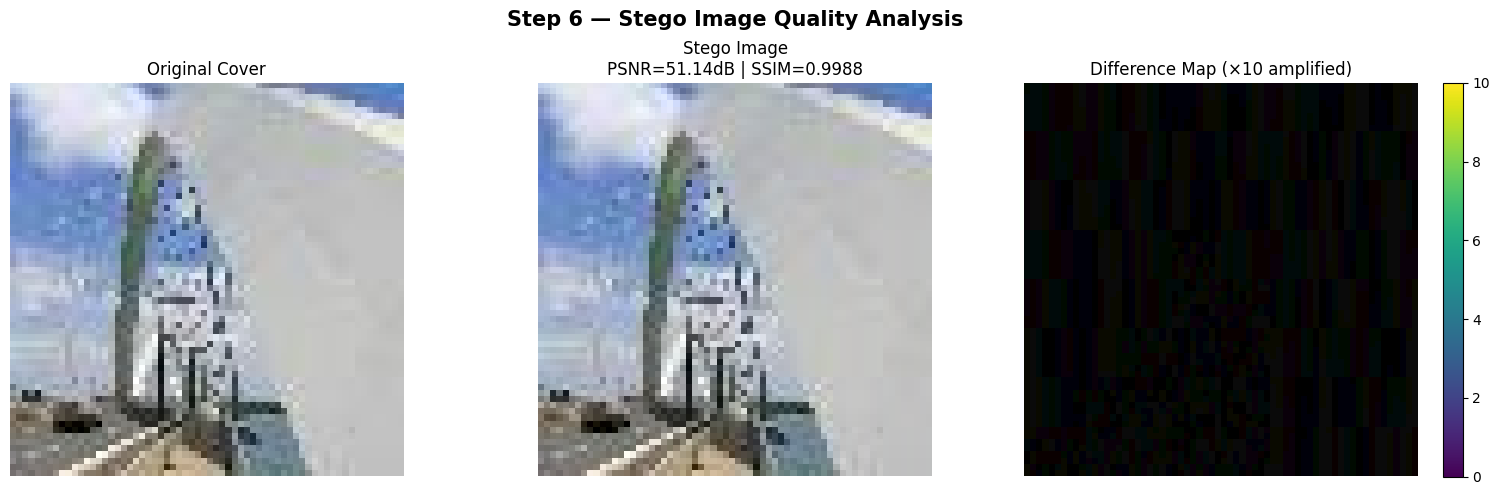

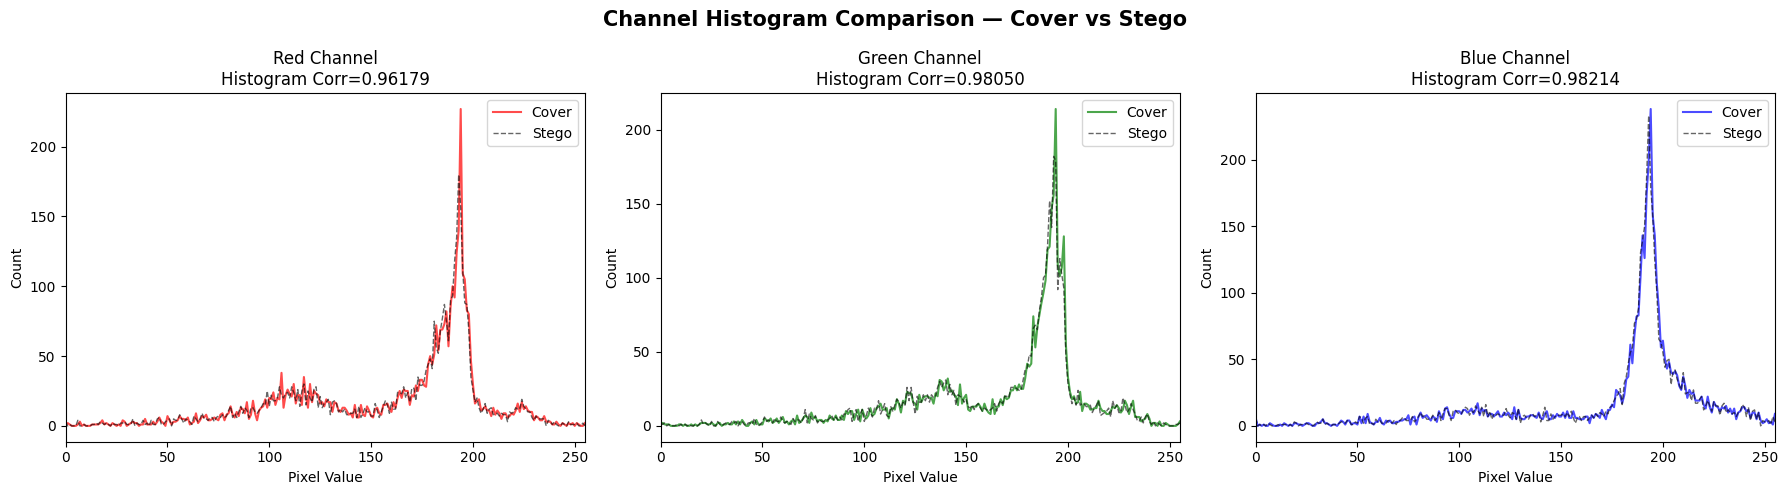

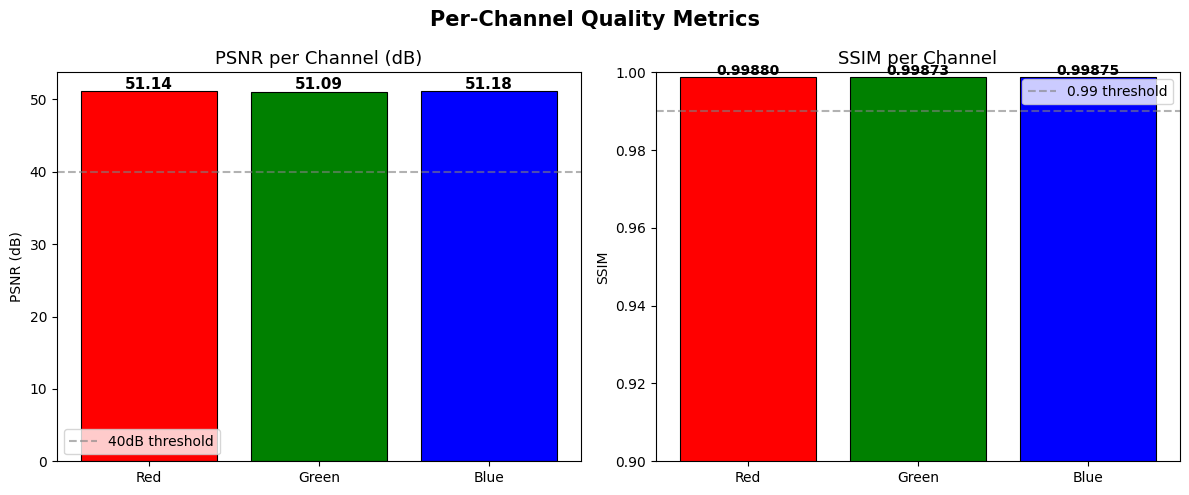

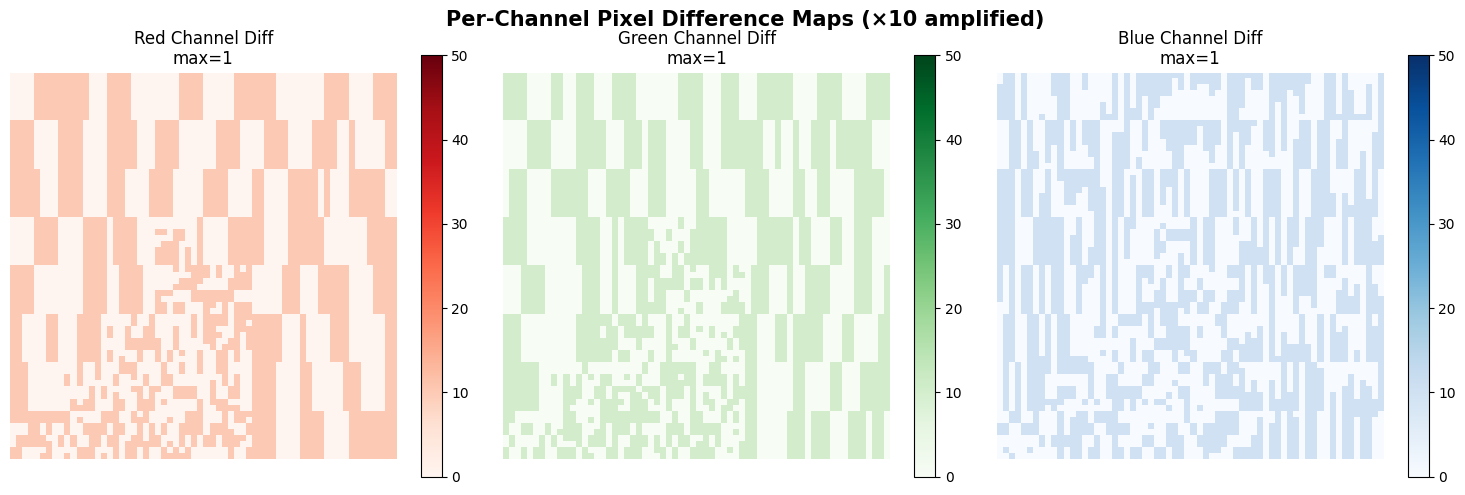

✅ All quality visualisations saved


In [ ]:
# ─────────────────────────────────────────────
# VIZ 10A: Cover vs Stego comparison + difference map
# ─────────────────────────────────────────────
diff_map = pixel_difference_map(cover_img, stego_img)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Step 6 — Stego Image Quality Analysis', fontsize=15, fontweight='bold')

axes[0].imshow(cover_img); axes[0].set_title('Original Cover'); axes[0].axis('off')
axes[1].imshow(stego_img); axes[1].set_title(
    f'Stego Image\nPSNR={psnr_total:.2f}dB | SSIM={ssim_total:.4f}'); axes[1].axis('off')
im = axes[2].imshow(diff_map); axes[2].set_title('Difference Map (×10 amplified)'); axes[2].axis('off')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig('step6_stego_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# VIZ 10B: Per-channel histogram comparison
# ─────────────────────────────────────────────
chan_colors = ['red', 'green', 'blue']
chan_labels = ['Red', 'Green', 'Blue']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Channel Histogram Comparison — Cover vs Stego', fontsize=15, fontweight='bold')

for c, (col, name) in enumerate(zip(chan_colors, chan_labels)):
    hist_cover = cv2.calcHist([cover_img], [c], None, [256], [0, 256]).flatten()
    hist_stego = cv2.calcHist([stego_img], [c], None, [256], [0, 256]).flatten()
    axes[c].plot(hist_cover, color=col,   alpha=0.7, linewidth=1.5, label='Cover')
    axes[c].plot(hist_stego, color='black', alpha=0.6, linewidth=1.0, linestyle='--', label='Stego')
    axes[c].set_title(f'{name} Channel\nHistogram Corr={hist_corr[name]:.5f}')
    axes[c].set_xlabel('Pixel Value'); axes[c].set_ylabel('Count')
    axes[c].legend(); axes[c].set_xlim(0, 255)

plt.tight_layout()
plt.savefig('step6_channel_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# VIZ 10C: Per-channel PSNR and SSIM bar charts
# ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Per-Channel Quality Metrics', fontsize=15, fontweight='bold')

bars1 = ax1.bar(chan_labels, [chan_psnr[n] for n in chan_labels],
                color=chan_colors, edgecolor='black', linewidth=0.8)
ax1.set_title('PSNR per Channel (dB)', fontsize=13)
ax1.set_ylabel('PSNR (dB)')
ax1.axhline(40, color='gray', linestyle='--', alpha=0.6, label='40dB threshold')
ax1.legend()
for bar, val in zip(bars1, [chan_psnr[n] for n in chan_labels]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

bars2 = ax2.bar(chan_labels, [chan_ssim[n] for n in chan_labels],
                color=chan_colors, edgecolor='black', linewidth=0.8)
ax2.set_title('SSIM per Channel', fontsize=13)
ax2.set_ylabel('SSIM')
ax2.set_ylim(0.9, 1.0)
ax2.axhline(0.99, color='gray', linestyle='--', alpha=0.6, label='0.99 threshold')
ax2.legend()
for bar, val in zip(bars2, [chan_ssim[n] for n in chan_labels]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{val:.5f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('step6_quality_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# VIZ 10D: Per-channel difference maps
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Per-Channel Pixel Difference Maps (×10 amplified)', fontsize=15, fontweight='bold')
cmaps = ['Reds', 'Greens', 'Blues']

for c, (cmap, name) in enumerate(zip(cmaps, chan_labels)):
    diff_c = np.abs(cover_img[:,:,c].astype(np.int16) - stego_img[:,:,c].astype(np.int16))
    im = axes[c].imshow(diff_c * 10, cmap=cmap, vmin=0, vmax=50)
    axes[c].set_title(f'{name} Channel Diff\nmax={diff_c.max()}')
    axes[c].axis('off')
    plt.colorbar(im, ax=axes[c])

plt.tight_layout()
plt.savefig('step6_channel_diff.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ All quality visualisations saved')

## CELL 11 — Multi-Image Benchmark

In [ ]:
# # ─────────────────────────────────────────────
# # CELL 11: Benchmark over N cover images
# # ─────────────────────────────────────────────
# N_IMAGES = 10

# results = []
# for i in range(N_IMAGES):
#     cover_i, _  = get_image(loader)
#     hidden_i, _ = get_image(loader)

#     payload_i    = prepare_hidden_image(hidden_i)
#     cipher_i     = KyberAESCipher()
#     enc_i        = cipher_i.encrypt(payload_i)

#     wgen_i = KyberChannelWeightGenerator(enc_i['shared_secret'], analyzer)
#     emb_i  = AdaptiveStegoEmbedder(analyzer, wgen_i, domain_sel)
#     stego_i, _ = emb_i.embed(cover_i, enc_i['encrypted_bytes'], verbose=False)

#     results.append({
#         'psnr':     compute_psnr(cover_i, stego_i),
#         'ssim':     compute_ssim(cover_i, stego_i),
#         'chan_psnr': compute_channel_psnr(cover_i, stego_i),
#         'chan_ssim': compute_channel_ssim(cover_i, stego_i),
#     })
#     print(f'  Image {i+1}/{N_IMAGES}: PSNR={results[-1]["psnr"]:.2f}dB SSIM={results[-1]["ssim"]:.4f}')

# psnr_vals = [r['psnr'] for r in results]
# ssim_vals = [r['ssim'] for r in results]
# print(f'\n📈 Mean PSNR: {np.mean(psnr_vals):.2f} ± {np.std(psnr_vals):.2f} dB')
# print(f'📈 Mean SSIM: {np.mean(ssim_vals):.5f} ± {np.std(ssim_vals):.5f}')

In [ ]:
# ─────────────────────────────────────────────
# CELL 11: Benchmark over N cover images
# (with automatic checkpointing every LOG_EVERY images)
# ─────────────────────────────────────────────
import json, os

N_IMAGES      = 5000
LOG_EVERY     = 1000
CHECKPOINT_PATH = '/content/benchmark_checkpoint.json'

# ── Resume from checkpoint if one exists ──
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, 'r') as f:
        ckpt = json.load(f)
    results      = ckpt['results']
    all_metadata = ckpt['all_metadata']
    start_idx    = len(results)
    print(f'✅ Resuming from checkpoint at image {start_idx:,}')
else:
    results      = []
    all_metadata = []
    start_idx    = 0
    print('🆕 Starting fresh benchmark')

# ── Main loop ──
for i in range(start_idx, N_IMAGES):
    cover_i, _  = get_image(loader)
    hidden_i, _ = get_image(loader)

    payload_i    = prepare_hidden_image(hidden_i)
    cipher_i     = KyberAESCipher()
    enc_i        = cipher_i.encrypt(payload_i)

    wgen_i  = KyberChannelWeightGenerator(enc_i['shared_secret'], analyzer)
    emb_i   = AdaptiveStegoEmbedder(analyzer, wgen_i, domain_sel)
    stego_i, meta_i = emb_i.embed(cover_i, enc_i['encrypted_bytes'], verbose=False)

    results.append({
        'psnr':      compute_psnr(cover_i, stego_i),
        'ssim':      compute_ssim(cover_i, stego_i),
        'chan_psnr': compute_channel_psnr(cover_i, stego_i),
        'chan_ssim': compute_channel_ssim(cover_i, stego_i),
    })
    all_metadata.extend(meta_i)

    completed = i + 1
    if completed % LOG_EVERY == 0:
        recent   = results[-LOG_EVERY:]
        run_psnr = np.mean([r['psnr'] for r in recent])
        run_ssim = np.mean([r['ssim'] for r in recent])
        pct_done = 100 * completed / N_IMAGES
        print(f'[{completed:>6}/{N_IMAGES}]  {pct_done:5.1f}% done  |  '
              f'Last {LOG_EVERY} avg → PSNR: {run_psnr:.2f} dB  SSIM: {run_ssim:.5f}')

        # ── Auto-save checkpoint every LOG_EVERY images ──
        ckpt_data = {
            'results':      results,
            'all_metadata': all_metadata,
        }
        with open(CHECKPOINT_PATH, 'w') as f:
            json.dump(ckpt_data, f)
        print(f'           💾 Checkpoint saved ({completed:,} images)')

# ── Final summary ──
psnr_vals = [r['psnr'] for r in results]
ssim_vals = [r['ssim'] for r in results]

print('\n' + '=' * 60)
print('          FULL DATASET BENCHMARK RESULTS')
print('=' * 60)
print(f'  Total images evaluated : {len(results):,}')
print(f'  Mean PSNR              : {np.mean(psnr_vals):.2f} ± {np.std(psnr_vals):.2f} dB')
print(f'  PSNR Range             : {np.min(psnr_vals):.2f} – {np.max(psnr_vals):.2f} dB')
print(f'  Mean SSIM              : {np.mean(ssim_vals):.5f} ± {np.std(ssim_vals):.5f}')
print(f'  SSIM Range             : {np.min(ssim_vals):.5f} – {np.max(ssim_vals):.5f}')
print('=' * 60)

🆕 Starting fresh benchmark


Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 227, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/util.py", line 136, in _remove_temp_dir
    rmtree(tempdir, onerror=onerror)
  File "/usr/lib/python3.12/shutil.py", line 759, in rmtree
    _rmtree_safe_fd(stack, onexc)
  File "/usr/lib/python3.12/shutil.py", line 703, in _rmtree_safe_fd
    onexc(func, path, err)
  File "/usr/lib/python3.12/shutil.py", line 750, in onexc
    return onerror(func, path, exc_info)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/shutil.py", line 662, in _rmtree_safe_fd
    os.rmdir(name, dir_fd=dirfd)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-jsq6f0ot'


[  1000/5000]   20.0% done  |  Last 1000 avg → PSNR: 51.40 dB  SSIM: 0.99931
           💾 Checkpoint saved (1,000 images)
[  2000/5000]   40.0% done  |  Last 1000 avg → PSNR: 51.41 dB  SSIM: 0.99935
           💾 Checkpoint saved (2,000 images)
[  3000/5000]   60.0% done  |  Last 1000 avg → PSNR: 51.41 dB  SSIM: 0.99937
           💾 Checkpoint saved (3,000 images)
[  4000/5000]   80.0% done  |  Last 1000 avg → PSNR: 51.40 dB  SSIM: 0.99934
           💾 Checkpoint saved (4,000 images)
[  5000/5000]  100.0% done  |  Last 1000 avg → PSNR: 51.40 dB  SSIM: 0.99939
           💾 Checkpoint saved (5,000 images)

          FULL DATASET BENCHMARK RESULTS
  Total images evaluated : 5,000
  Mean PSNR              : 51.40 ± 0.24 dB
  PSNR Range             : 50.71 – 54.17 dB
  Mean SSIM              : 0.99935 ± 0.00072
  SSIM Range             : 0.98412 – 0.99998


### Recovering results from last checkpoint

In [ ]:
# # ─────────────────────────────────────────────
# # RECOVERY CELL — run this after any disconnection
# # to reload results from checkpoint before running VIZ cells
# # ─────────────────────────────────────────────
# import json

# CHECKPOINT_PATH = '/content/benchmark_checkpoint.json'

# with open(CHECKPOINT_PATH, 'r') as f:
#     ckpt = json.load(f)

# results      = ckpt['results']
# all_metadata = ckpt['all_metadata']
# N_IMAGES     = len(results)

# psnr_vals = [r['psnr'] for r in results]
# ssim_vals = [r['ssim'] for r in results]

# print(f'✅ Loaded {N_IMAGES:,} results from checkpoint')
# print(f'   Mean PSNR : {np.mean(psnr_vals):.2f} ± {np.std(psnr_vals):.2f} dB')
# print(f'   Mean SSIM : {np.mean(ssim_vals):.5f} ± {np.std(ssim_vals):.5f}')

### VIZ 11 — Benchmark Summary Charts

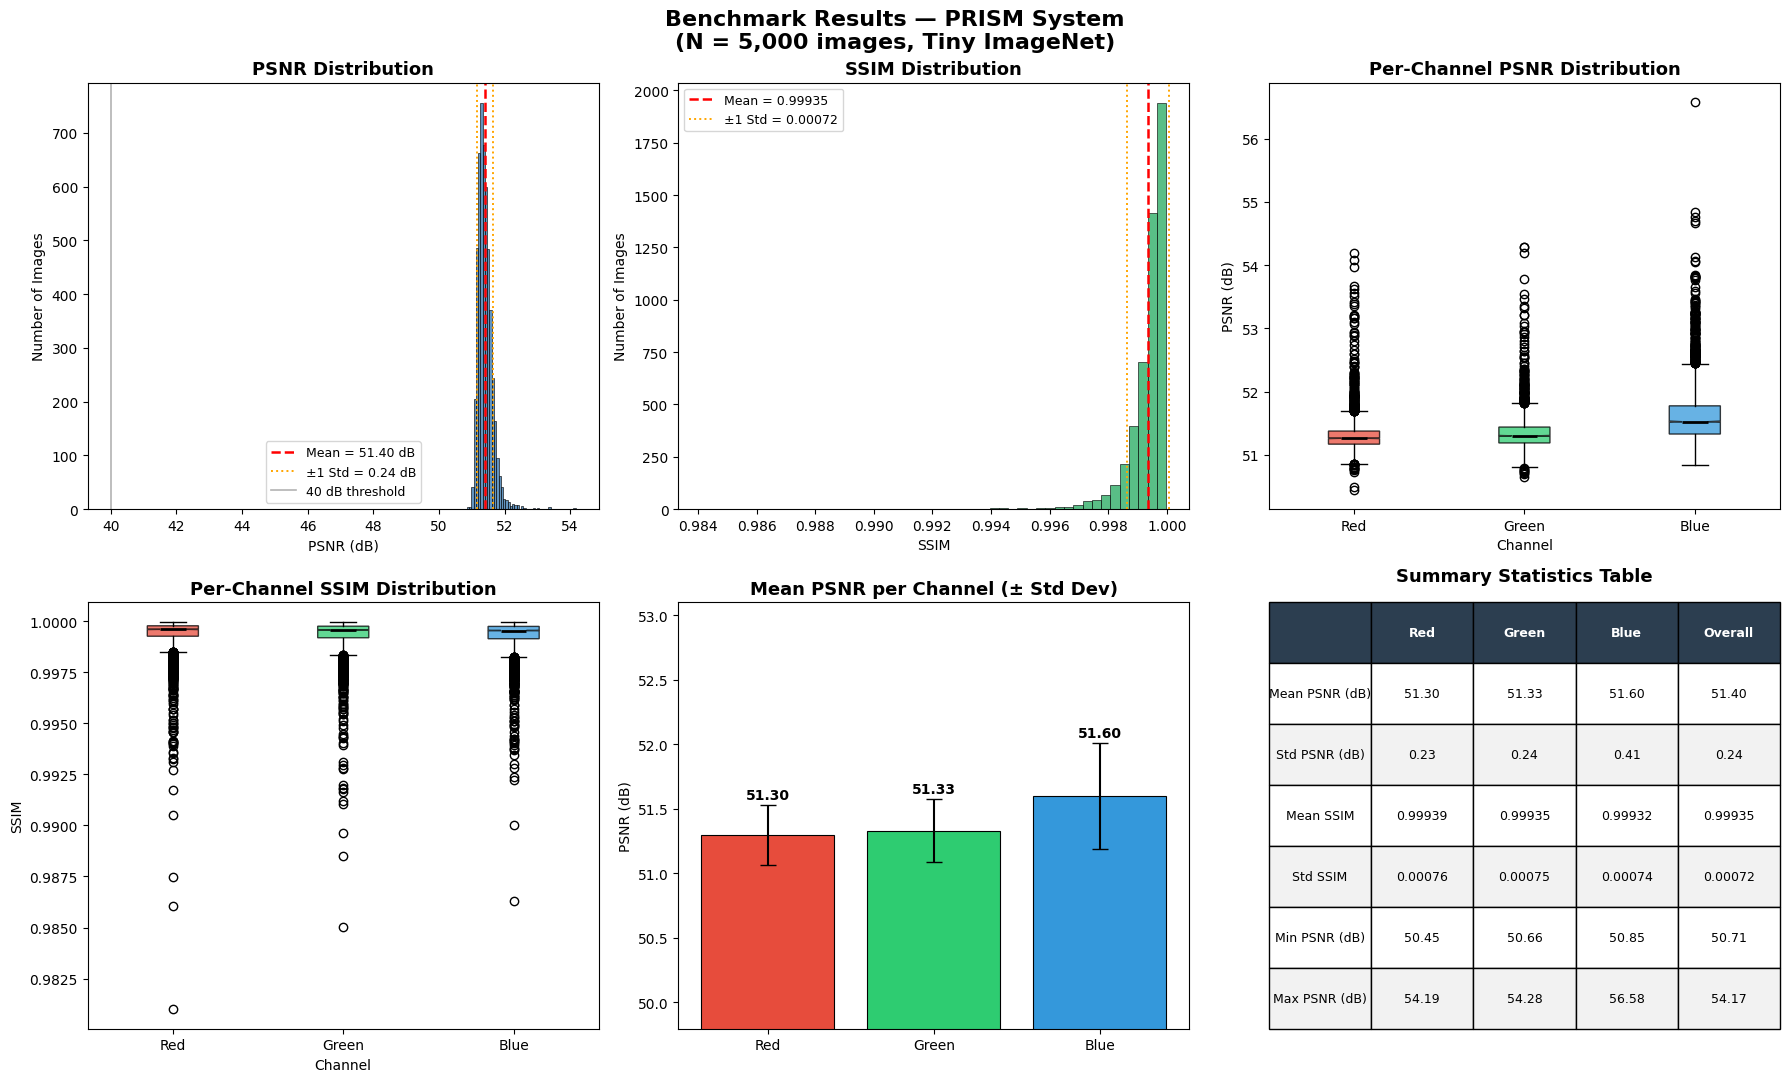

✅ Benchmark summary saved → benchmark_summary.png


In [ ]:
# ─────────────────────────────────────────────
# VIZ 11: Benchmark Visualisation (Full Dataset Summary)
# ─────────────────────────────────────────────

# ── Pre-compute all summary statistics ──
psnr_vals  = [r['psnr'] for r in results]
ssim_vals  = [r['ssim'] for r in results]

channel_psnr_data = {
    'Red':   [r['chan_psnr']['Red']   for r in results],
    'Green': [r['chan_psnr']['Green'] for r in results],
    'Blue':  [r['chan_psnr']['Blue']  for r in results],
}
channel_ssim_data = {
    'Red':   [r['chan_ssim']['Red']   for r in results],
    'Green': [r['chan_ssim']['Green'] for r in results],
    'Blue':  [r['chan_ssim']['Blue']  for r in results],
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(f'Benchmark Results — PRISM System\n(N = {N_IMAGES:,} images, Tiny ImageNet)',
             fontsize=16, fontweight='bold')

# ── Plot 1: PSNR Distribution (histogram) ──
axes[0,0].hist(psnr_vals, bins=50, color='steelblue', edgecolor='black',
               linewidth=0.5, alpha=0.85)
axes[0,0].axvline(np.mean(psnr_vals), color='red', linestyle='--', linewidth=1.8,
                   label=f'Mean = {np.mean(psnr_vals):.2f} dB')
axes[0,0].axvline(np.mean(psnr_vals) - np.std(psnr_vals), color='orange',
                   linestyle=':', linewidth=1.4, label=f'±1 Std = {np.std(psnr_vals):.2f} dB')
axes[0,0].axvline(np.mean(psnr_vals) + np.std(psnr_vals), color='orange',
                   linestyle=':', linewidth=1.4)
axes[0,0].axvline(40, color='gray', linestyle='-', linewidth=1.2, alpha=0.6,
                   label='40 dB threshold')
axes[0,0].set_title('PSNR Distribution', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('PSNR (dB)'); axes[0,0].set_ylabel('Number of Images')
axes[0,0].legend(fontsize=9)

# ── Plot 2: SSIM Distribution (histogram) ──
axes[0,1].hist(ssim_vals, bins=50, color='mediumseagreen', edgecolor='black',
               linewidth=0.5, alpha=0.85)
axes[0,1].axvline(np.mean(ssim_vals), color='red', linestyle='--', linewidth=1.8,
                   label=f'Mean = {np.mean(ssim_vals):.5f}')
axes[0,1].axvline(np.mean(ssim_vals) - np.std(ssim_vals), color='orange',
                   linestyle=':', linewidth=1.4, label=f'±1 Std = {np.std(ssim_vals):.5f}')
axes[0,1].axvline(np.mean(ssim_vals) + np.std(ssim_vals), color='orange',
                   linestyle=':', linewidth=1.4)
axes[0,1].set_title('SSIM Distribution', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('SSIM'); axes[0,1].set_ylabel('Number of Images')
axes[0,1].legend(fontsize=9)

# ── Plot 3: Per-Channel PSNR Box Plot ──
box_psnr = [channel_psnr_data[n] for n in ['Red', 'Green', 'Blue']]
bp1 = axes[0,2].boxplot(box_psnr, labels=['Red', 'Green', 'Blue'],
                         patch_artist=True, notch=True,
                         medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp1['boxes'], ['#e74c3c', '#2ecc71', '#3498db']):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[0,2].set_title('Per-Channel PSNR Distribution', fontsize=13, fontweight='bold')
axes[0,2].set_ylabel('PSNR (dB)')
axes[0,2].set_xlabel('Channel')

# ── Plot 4: Per-Channel SSIM Box Plot ──
box_ssim = [channel_ssim_data[n] for n in ['Red', 'Green', 'Blue']]
bp2 = axes[1,0].boxplot(box_ssim, labels=['Red', 'Green', 'Blue'],
                         patch_artist=True, notch=True,
                         medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp2['boxes'], ['#e74c3c', '#2ecc71', '#3498db']):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[1,0].set_title('Per-Channel SSIM Distribution', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('SSIM')
axes[1,0].set_xlabel('Channel')

# ── Plot 5: Mean ± Std bar chart for PSNR per channel ──
chan_names  = ['Red', 'Green', 'Blue']
chan_colors = ['#e74c3c', '#2ecc71', '#3498db']
means_psnr  = [np.mean(channel_psnr_data[c]) for c in chan_names]
stds_psnr   = [np.std(channel_psnr_data[c])  for c in chan_names]

bars = axes[1,1].bar(chan_names, means_psnr, yerr=stds_psnr, capsize=6,
                      color=chan_colors, edgecolor='black', linewidth=0.8,
                      error_kw=dict(elinewidth=1.5, ecolor='black'))
axes[1,1].set_title('Mean PSNR per Channel (± Std Dev)', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('PSNR (dB)')
axes[1,1].set_ylim(min(means_psnr) - 1.5, max(means_psnr) + 1.5)
for bar, mean, std in zip(bars, means_psnr, stds_psnr):
    axes[1,1].text(bar.get_x() + bar.get_width() / 2,
                   bar.get_height() + std + 0.05,
                   f'{mean:.2f}', ha='center', fontsize=10, fontweight='bold')

# ── Plot 6: Summary statistics table ──
axes[1,2].axis('off')
table_data = [
    ['Metric',            'Red',
     f'{np.mean(channel_psnr_data["Red"]):.2f} ± {np.std(channel_psnr_data["Red"]):.2f}',
     f'{np.mean(channel_psnr_data["Green"]):.2f} ± {np.std(channel_psnr_data["Green"]):.2f}',
     f'{np.mean(channel_psnr_data["Blue"]):.2f} ± {np.std(channel_psnr_data["Blue"]):.2f}'],
]

summary_rows = [
    ['',                   'Red',          'Green',        'Blue',         'Overall'],
    ['Mean PSNR (dB)',
     f'{np.mean(channel_psnr_data["Red"]):.2f}',
     f'{np.mean(channel_psnr_data["Green"]):.2f}',
     f'{np.mean(channel_psnr_data["Blue"]):.2f}',
     f'{np.mean(psnr_vals):.2f}'],
    ['Std PSNR (dB)',
     f'{np.std(channel_psnr_data["Red"]):.2f}',
     f'{np.std(channel_psnr_data["Green"]):.2f}',
     f'{np.std(channel_psnr_data["Blue"]):.2f}',
     f'{np.std(psnr_vals):.2f}'],
    ['Mean SSIM',
     f'{np.mean(channel_ssim_data["Red"]):.5f}',
     f'{np.mean(channel_ssim_data["Green"]):.5f}',
     f'{np.mean(channel_ssim_data["Blue"]):.5f}',
     f'{np.mean(ssim_vals):.5f}'],
    ['Std SSIM',
     f'{np.std(channel_ssim_data["Red"]):.5f}',
     f'{np.std(channel_ssim_data["Green"]):.5f}',
     f'{np.std(channel_ssim_data["Blue"]):.5f}',
     f'{np.std(ssim_vals):.5f}'],
    ['Min PSNR (dB)',
     f'{np.min(channel_psnr_data["Red"]):.2f}',
     f'{np.min(channel_psnr_data["Green"]):.2f}',
     f'{np.min(channel_psnr_data["Blue"]):.2f}',
     f'{np.min(psnr_vals):.2f}'],
    ['Max PSNR (dB)',
     f'{np.max(channel_psnr_data["Red"]):.2f}',
     f'{np.max(channel_psnr_data["Green"]):.2f}',
     f'{np.max(channel_psnr_data["Blue"]):.2f}',
     f'{np.max(psnr_vals):.2f}'],
]

tbl = axes[1,2].table(cellText=summary_rows[1:], colLabels=summary_rows[0],
                       cellLoc='center', loc='center',
                       bbox=[0.0, 0.0, 1.0, 1.0])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)

# Style header row
for j in range(5):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Alternating row shading
row_colors = ['#f2f2f2', '#ffffff']
for row_idx in range(1, len(summary_rows)):
    for col_idx in range(5):
        tbl[row_idx, col_idx].set_facecolor(row_colors[row_idx % 2])

axes[1,2].set_title('Summary Statistics Table', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('benchmark_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Benchmark summary saved → benchmark_summary.png')

## CELL 12 — Embedding Metadata Analysis

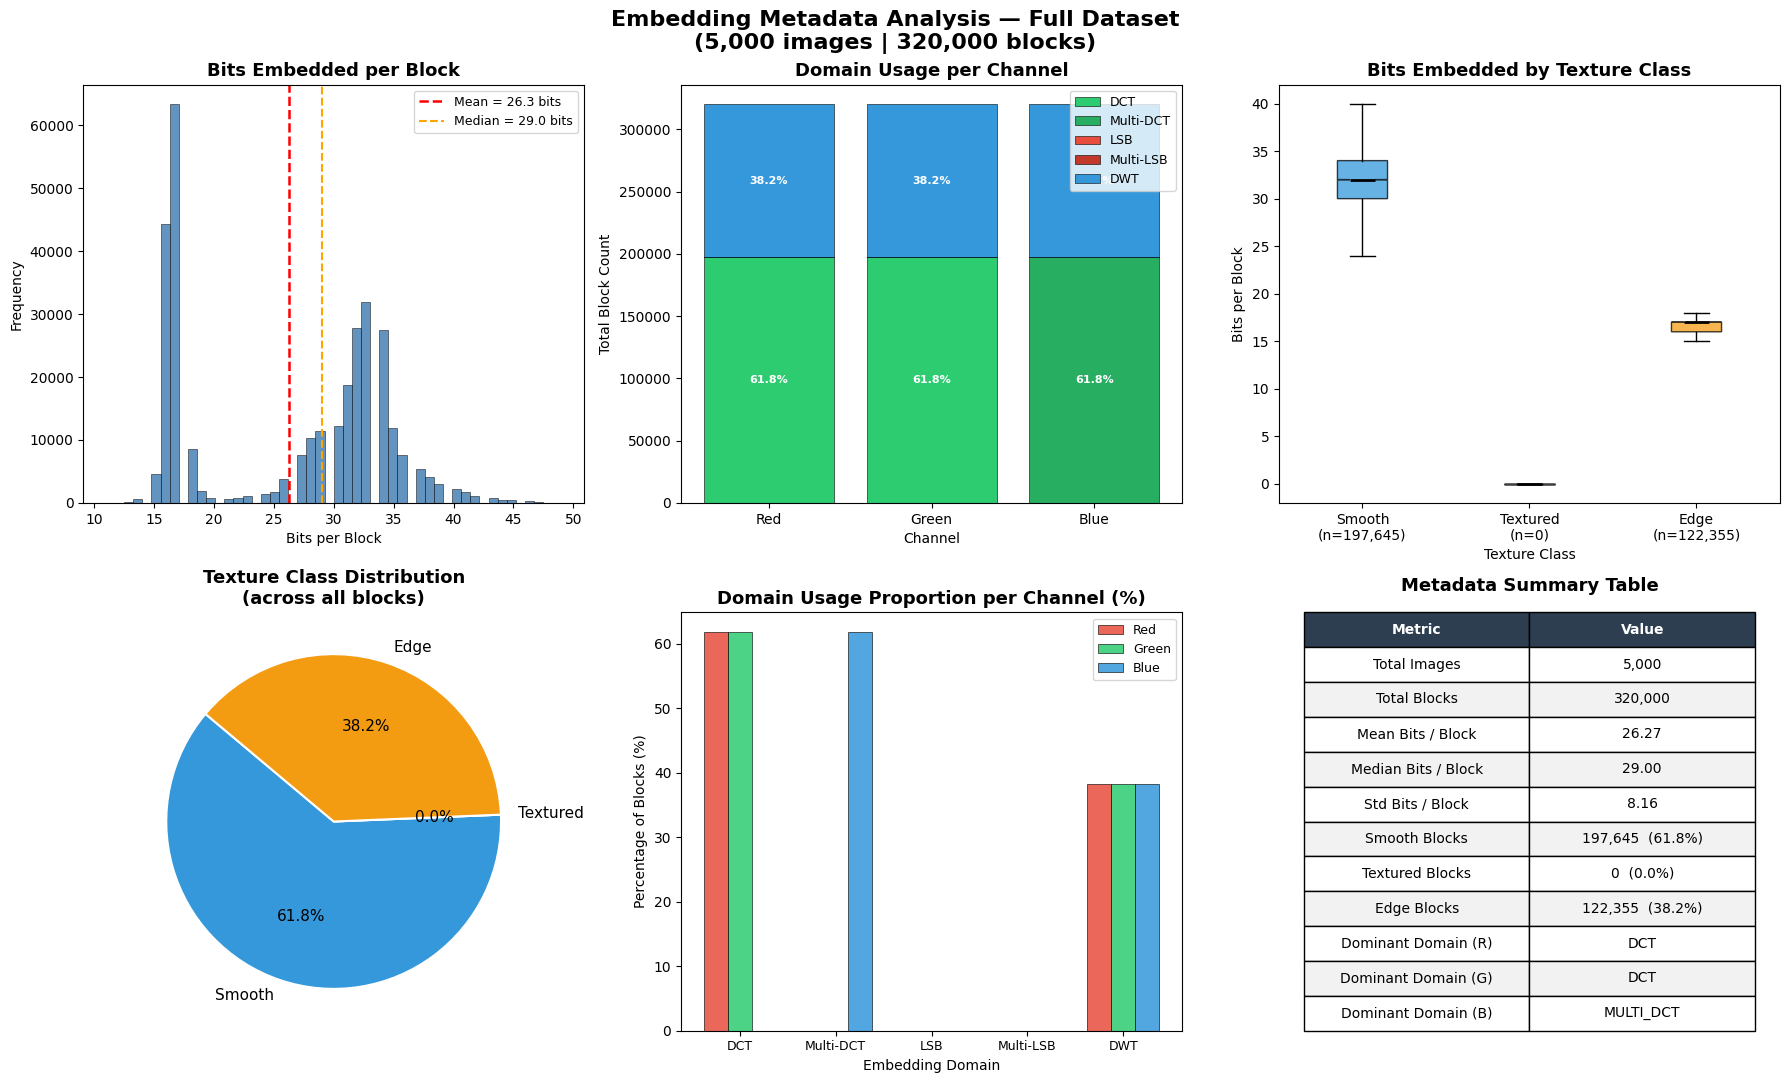

✅ Metadata analysis saved → embedding_metadata_analysis.png
   Total blocks analysed: 320,000 across 5,000 images


In [ ]:
# ─────────────────────────────────────────────
# VIZ 12: Embedding Metadata Analysis (Full Dataset)
# ─────────────────────────────────────────────
from collections import defaultdict, Counter

# ── Aggregate metadata across all images ──
domain_usage   = defaultdict(Counter)
bits_per_block = []
texture_list   = []

for block_log in all_metadata:
    total_bits = sum(d['bits'] for d in block_log['domains'].values())
    bits_per_block.append(total_bits)
    texture_list.append(block_log['texture'])
    for ch, info in block_log['domains'].items():
        domain_usage[ch][info['domain']] += 1

# ── Texture class counts ──
tex_bits = defaultdict(list)
for tex, bits in zip(texture_list, bits_per_block):
    tex_bits[tex].append(bits)

tex_order  = ['smooth', 'textured', 'edge']
tex_colors = ['#3498db', '#e74c3c', '#f39c12']
tex_counts = {t: len(tex_bits.get(t, [])) for t in tex_order}
total_blocks = sum(tex_counts.values())

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(f'Embedding Metadata Analysis — Full Dataset\n({N_IMAGES:,} images | {total_blocks:,} blocks)',
             fontsize=16, fontweight='bold')

# ── Plot 1: Bits per block distribution (histogram) ──
axes[0,0].hist(bits_per_block, bins=50, color='steelblue',
               edgecolor='black', linewidth=0.4, alpha=0.85)
axes[0,0].axvline(np.mean(bits_per_block), color='red', linestyle='--', linewidth=1.8,
                   label=f'Mean = {np.mean(bits_per_block):.1f} bits')
axes[0,0].axvline(np.median(bits_per_block), color='orange', linestyle='--', linewidth=1.5,
                   label=f'Median = {np.median(bits_per_block):.1f} bits')
axes[0,0].set_title('Bits Embedded per Block', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Bits per Block')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend(fontsize=9)

# ── Plot 2: Domain usage per channel (stacked bar) ──
all_domains = ['dct', 'multi_dct', 'lsb', 'multi_lsb', 'dwt']
dom_colors  = ['#2ecc71', '#27ae60', '#e74c3c', '#c0392b', '#3498db']
dom_labels  = ['DCT', 'Multi-DCT', 'LSB', 'Multi-LSB', 'DWT']
x_ticks     = ['Red', 'Green', 'Blue']
bottoms     = np.zeros(3)

for d, dc, dl in zip(all_domains, dom_colors, dom_labels):
    vals = [domain_usage[ch][d] for ch in range(3)]
    axes[0,1].bar(x_ticks, vals, bottom=bottoms, label=dl,
                   color=dc, edgecolor='black', linewidth=0.4)
    bottoms += np.array(vals, dtype=float)

axes[0,1].set_title('Domain Usage per Channel', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Total Block Count')
axes[0,1].set_xlabel('Channel')
axes[0,1].legend(fontsize=9, loc='upper right')

# Add percentage labels on each segment
for ch_idx, ch_name in enumerate(x_ticks):
    running = 0
    total_ch = sum(domain_usage[ch_idx][d] for d in all_domains)
    if total_ch > 0: # Add check for zero division
        for d, dc in zip(all_domains, dom_colors):
            val = domain_usage[ch_idx][d]
            if val / total_ch > 0.05:   # only label segments > 5%
                axes[0,1].text(ch_idx, running + val / 2,
                               f'{100*val/total_ch:.1f}%',
                               ha='center', va='center', fontsize=8,
                               fontweight='bold', color='white')
            running += val

# ── Plot 3: Bits per block by texture class (box plot) ──
bp = axes[0,2].boxplot([tex_bits.get(t, [0]) for t in tex_order],
                        labels=[f'{t.capitalize()}\n(n={tex_counts[t]:,})' for t in tex_order],
                        patch_artist=True, notch=True,
                        medianprops=dict(color='black', linewidth=2),
                        showfliers=False)   # hide outlier dots at 100k scale
for patch, col in zip(bp['boxes'], tex_colors):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[0,2].set_title('Bits Embedded by Texture Class', fontsize=13, fontweight='bold')
axes[0,2].set_ylabel('Bits per Block')
axes[0,2].set_xlabel('Texture Class')

# ── Plot 4: Texture class distribution pie chart ──
axes[1,0].pie(
    [tex_counts[t] for t in tex_order],
    labels=[t.capitalize() for t in tex_order],
    colors=tex_colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1,0].set_title('Texture Class Distribution\n(across all blocks)', fontsize=13, fontweight='bold')

# ── Plot 5: Domain usage proportion per channel (grouped bar, normalised) ──
x_pos  = np.arange(len(all_domains))
bar_w  = 0.25
chan_colors_rgb = ['#e74c3c', '#2ecc71', '#3498db']

for ch_idx, (ch_name, ch_col) in enumerate(zip(x_ticks, chan_colors_rgb)):
    total_ch = sum(domain_usage[ch_idx][d] for d in all_domains)
    # Only calculate proportions if total_ch is greater than 0
    if total_ch > 0:
        proportions = [100 * domain_usage[ch_idx][d] / total_ch for d in all_domains]
        axes[1,1].bar(x_pos + ch_idx * bar_w, proportions, width=bar_w,
                       label=ch_name, color=ch_col, edgecolor='black',
                       linewidth=0.5, alpha=0.85)
    else:
        # If no data for the channel, plot an empty bar or handle as appropriate
        axes[1,1].bar(x_pos + ch_idx * bar_w, [0]*len(all_domains), width=bar_w,
                       label=ch_name, color=ch_col, edgecolor='black',
                       linewidth=0.5, alpha=0.85) # Plot empty bars

axes[1,1].set_xticks(x_pos + bar_w)
axes[1,1].set_xticklabels(dom_labels, fontsize=9)
axes[1,1].set_title('Domain Usage Proportion per Channel (%)', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Percentage of Blocks (%)')
axes[1,1].set_xlabel('Embedding Domain')
axes[1,1].legend(fontsize=9)

# ── Plot 6: Summary statistics table ──
axes[1,2].axis('off')
summary_rows = [
    ['Metric', 'Value'],
    ['Total Images',          f'{N_IMAGES:,}'],
    ['Total Blocks',          f'{total_blocks:,}'],
    ['Mean Bits / Block',     f'{np.mean(bits_per_block):.2f}'],
    ['Median Bits / Block',   f'{np.median(bits_per_block):.2f}'],
    ['Std Bits / Block',      f'{np.std(bits_per_block):.2f}'],
    ['Smooth Blocks',         f'{tex_counts["smooth"]:,}  ({100*tex_counts["smooth"]/total_blocks:.1f}%)'],
    ['Textured Blocks',       f'{tex_counts["textured"]:,}  ({100*tex_counts["textured"]/total_blocks:.1f}%)'],
    ['Edge Blocks',           f'{tex_counts["edge"]:,}  ({100*tex_counts["edge"]/total_blocks:.1f}%)'],
    ['Dominant Domain (R)',   max(all_domains, key=lambda d: domain_usage[0][d]).upper()],
    ['Dominant Domain (G)',   max(all_domains, key=lambda d: domain_usage[1][d]).upper()],
    ['Dominant Domain (B)',   max(all_domains, key=lambda d: domain_usage[2][d]).upper()],
]

tbl = axes[1,2].table(cellText=summary_rows[1:], colLabels=summary_rows[0],
                       cellLoc='center', loc='center',
                       bbox=[0.05, 0.0, 0.9, 1.0])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

for j in range(2):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
row_colors = ['#f2f2f2', '#ffffff']
for row_idx in range(1, len(summary_rows)):
    for col_idx in range(2):
        tbl[row_idx, col_idx].set_facecolor(row_colors[row_idx % 2])

axes[1,2].set_title('Metadata Summary Table', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('embedding_metadata_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Metadata analysis saved → embedding_metadata_analysis.png')
print(f'   Total blocks analysed: {total_blocks:,} across {N_IMAGES:,} images')

---
## 📋 Summary of Outputs
| File | Description |
|------|-------------|
| `sample_images.png` | Sample images from Tiny ImageNet |
| `step1_encryption.png` | Cover, hidden, and encrypted byte visualisation |
| `step2_texture_analysis.png` | ML texture & dominant channel maps |
| `step2_texture_distribution.png` | Block texture type pie chart |
| `step3_channel_weights.png` | Kyber-controlled channel weight heatmaps |
| `step3_weight_distribution.png` | Weight distribution violin plot |
| `step4_domain_selection.png` | Per-channel domain selection map |
| `step6_stego_comparison.png` | Cover vs stego + difference map |
| `step6_channel_histograms.png` | Per-channel histogram comparison |
| `step6_quality_metrics.png` | PSNR/SSIM bar charts |
| `step6_channel_diff.png` | Per-channel difference maps |
| `benchmark_summary.png` | Multi-image benchmark results |
| `embedding_metadata_analysis.png` | Domain usage, bits distribution |